### Only to be used locally, venv works properly there

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path

# Cognate Evolution

In [2]:
def evolve_cognate(root, root_state, gain_rate, loss_rate, seed=None):
    """
    Simulate evolution of a single binary cognate.
    Returns states keyed by leaf name.
    """

    if seed is not None:
        np.random.seed(seed)

    states = {root: root_state}
    total_rate = gain_rate + loss_rate

    def evolve_branch(parent, child):
        parent_state = states[parent]
        t = child.branch_length

        if total_rate == 0:
            states[child] = parent_state
            return

        exp_term = np.exp(-total_rate * t)

        if parent_state == 0:
            p01 = (gain_rate / total_rate) * (1 - exp_term)
            states[child] = int(np.random.rand() < p01)
        else:
            p10 = (loss_rate / total_rate) * (1 - exp_term)
            states[child] = int(not (np.random.rand() < p10))

    def traverse(node):
        if node.left is not None:
            evolve_branch(node, node.left)
            traverse(node.left)
        if node.right is not None:
            evolve_branch(node, node.right)
            traverse(node.right)

    traverse(root)

    # Return only leaf states keyed by leaf name
    leaf_states = {}
    for node, state in states.items():
        if node.is_leaf():
            leaf_states[node.name] = state

    return leaf_states

# Tree Priors

In [3]:
def yule_prior(n_leaves, birth_rate=1.0, seed=None):
    """
    Simulate an ultrametric phylogenetic tree under the Yule prior.
    ----------
    Parameters:
    n_leaves (int): Number of leaves in the tree.
    birth_rate (float): Birth rate for the tree generation, defaults to 1.0.
    seed (int, optional): Random seed for reproducibility, defaults to None.

    Returns:
    root (Node): Generated tree.
    ----------
    """

    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Start at time 0 with one lineage
    root = Node(birth_time=0.0)
    active_lineages = [root]

    current_time = 0.0

    # Forward simulation
    while len(active_lineages) < n_leaves:
        k = len(active_lineages)
        wait_time = np.random.exponential(1.0 / (k * birth_rate))
        current_time += wait_time

        # choose lineage to split
        lineage = random.choice(active_lineages)

        # create children at current_time
        left = Node(parent=lineage, birth_time=current_time)
        right = Node(parent=lineage, birth_time=current_time)

        lineage.left = left
        lineage.right = right

        # branch length from parent = split_time - birth_time
        lineage.branch_length = current_time - lineage.birth_time

        # update active set
        active_lineages.remove(lineage)
        active_lineages.extend([left, right])

    # Final tree height
    total_height = current_time

    # Extend all remaining active lineages to total_height
    for leaf in active_lineages:
        leaf.branch_length = total_height - leaf.birth_time

    # Label leaves
    for i, leaf in enumerate(active_lineages):
        leaf.name = f"t{i+1}"

    return root

def birth_death_prior(n_leaves, birth_rate=1.0, death_rate=0.0, seed=None):
    """
    Simulate an ultrametric phylogenetic tree under the birthDeath prior.
    ----------
    Parameters:
    n_leaves (int): Number of leaves in the tree.
    birth_rate (float): Birth rate for the tree generation, defaults to 1.0.
    death_rate (float): Death rate for the tree generation, defaults to 0.0.
    seed (int, optional): Random seed for reproducibility, defaults to None.

    Returns:
    root (Node): Generated tree.
    ----------
    root : Node
    """

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    lam = birth_rate
    mu = death_rate

    if mu >= lam:
        raise ValueError("Require birth_rate > death_rate for a proper "
                         "BD prior.")

    deltas = []
    for k in range(2, n_leaves + 1):
        rate = (k - 1) * (lam - mu)
        deltas.append(np.random.exponential(1.0 / rate))

    # cumulative heights from present (0) backwards
    heights = np.cumsum(deltas)

    # 2) Initialize leaves at time 0
    leaves = [Node(birth_time=0.0) for _ in range(n_leaves)]
    for i, leaf in enumerate(leaves):
        leaf.name = f"t{i+1}"

    active = leaves[:]

    # 3) Build random ranked topology
    for h in heights:
        a, b = random.sample(active, 2)

        parent = Node(parent=None, birth_time=h)
        parent.left = a
        parent.right = b

        a.parent = parent
        b.parent = parent

        # branch lengths = parent time - child time
        a.branch_length = parent.birth_time - a.birth_time
        b.branch_length = parent.birth_time - b.birth_time

        active.remove(a)
        active.remove(b)
        active.append(parent)

    root = active[0]

    # root branch length conventionally 0
    root.branch_length = 0.0

    return root


# Tree Class

In [4]:
class Node:
    """
    Tree Node class for representing phylogenetic trees.
    """
    def __init__(self, name=None, parent=None, birth_time=0.0):
        """
        Initialise tree node.
        ----------
        Parameters:
        name (str, optional): Name of the node, defaults to None.
        parent (Node, optional): Parent node, defaults to None.
        birth_time (float): Time of node birth, defaults to 0.0.
        ----------
        """
        self.name = name
        self.parent = parent
        self.left = None
        self.right = None
        self.birth_time = birth_time
        self.branch_length = 0.0

    def is_leaf(self):
        """
        Check if the node is a leaf (i.e., has no children).
        """
        return self.left is None and self.right is None

class Tree:
    """
    Tree class for representing phylogenetic trees, containing Nodes.
    """
    allowed_tree_methods = ['yule', 'birthDeath']
    
    def __init__(self, n_leaves, method='yule', birth_rate=1.0,
                      death_rate=0.0, seed=None):
        """
        Generate (ultrametric) tree with a specified number of leaves using a
        given method.
        ----------
        Parameters:
        n_leaves (int): Number of leaves in the tree.
        method (str): Method to generate the tree ('yule' or 'birthDeath').
        birth_rate (float): Birth rate for the tree generation,
            defaults to 1.0.
        death_rate (float): Death rate for the tree generation,
            defaults to 0.0.
        seed (int, optional): Random seed for reproducibility,
            defaults to None.
        ----------
        """
        self.seed = seed
        if method not in self.allowed_tree_methods:
            raise ValueError("Invalid method. Choose from "
                             f"{self.allowed_tree_methods}.")
        if method == 'yule':
            self.root = yule_prior(n_leaves, birth_rate, seed)
        elif method == 'birthDeath':
            self.root = birth_death_prior(n_leaves, birth_rate, death_rate,
                                         seed)
        self.method = method
        print(f"Generated {method} tree with {n_leaves} leaves.")
        
    def plot(self):
        if self.root is None:
            raise ValueError("Tree is empty.")

        self._assign_y_positions()

        fig, ax = plt.subplots(figsize=(8, 5))
        self._plot_node(self.root, ax, 0)

        ax.invert_yaxis()
        ax.set_yticks([])
        ax.set_xlabel("Time / Branch length")

        plt.show()
    
    def _plot_node(self, node, ax, x):
        if node is None:
            return

        x_end = x + node.branch_length

        # Draw horizontal branch
        ax.plot([x, x_end], [node.y, node.y], 'k-')

        if not node.is_leaf():
            # Draw vertical connector between children
            y_left = node.left.y
            y_right = node.right.y
            ax.plot([x_end, x_end], [y_left, y_right], 'k-')

            # Recurse
            self._plot_node(node.left, ax, x_end)
            self._plot_node(node.right, ax, x_end)
        else:
            # Label leaf
            ax.text(x_end + 0.1, node.y, node.name,
                    va='center')

    def _assign_y_positions(self):
        """
        Assign y positions to leaves (evenly spaced).
        """
        self._y_counter = 0
        def dfs(node):
            if node.is_leaf():
                node.y = self._y_counter
                self._y_counter += 1
            else:
                dfs(node.left)
                dfs(node.right)
                node.y = (node.left.y + node.right.y) / 2
        dfs(self.root)

    def get_leaf_names(self):
        leaves = []
        def collect(node):
            if node.is_leaf():
                leaves.append(node.name)
            else:
                collect(node.left)
                collect(node.right)
        collect(self.root)
        self.leaves = leaves
        return leaves

    def generate_independent_data(self, n_sites,
                                gain_rate=0.4, loss_rate=0.6,
                                root_freq=0.3, ascertain=True):
        
        languages = self.get_leaf_names()
        rows = []

        for _ in range(n_sites):
            root_state = int(np.random.rand() < root_freq)
            states = evolve_cognate(self.root, root_state,
                                    gain_rate, loss_rate)
            rows.append([states[lang] for lang in languages])

        df = pd.DataFrame(rows, columns=languages)
        df.index = [f"cog_{i}" for i in range(len(df))]
        if ascertain:
            df = df.loc[df.sum(axis=1) > 0].copy()
        return df
        

In [5]:
# Rewrite this based on if t1 exists only then t2 has chance of being there etc
def generate_dependent_dataset(tree, languages,
                               n_blocks=50,
                               block_size=5,
                               base_gain=0.4,
                               base_loss=0.6,
                               root_freq=0.3,
                               rate_multipliers=(0.5, 2.0)):
    """
    Generates a cognate matrix with weak site dependence via
    shared latent rate regimes.
    """
    rows = []

    for block in range(n_blocks):
        rate_multiplier = np.random.choice(rate_multipliers)

        for _ in range(block_size):
            root_state = int(np.random.rand() < root_freq)
            states = evolve_cognate(
                tree,
                root_state,
                gain_rate=base_gain * rate_multiplier,
                loss_rate=base_loss * rate_multiplier
            )
            rows.append([states[lang] for lang in languages])

    df = pd.DataFrame(rows, columns=languages)
    df.index = [f"cog_{i}" for i in range(len(df))]
    return df


# File Generation

In [6]:
def df_to_sequences(df):
    """
    Rows = cognates, columns = languages
    Output: {language: '010101...'}
    """
    sequences = {}
    for lang in df.columns:
        sequences[lang] = "".join(df[lang].astype(str).tolist())
    return sequences

def write_nexus(df, outfile):
    sequences = df_to_sequences(df)

    taxa = list(sequences.keys())
    ntax = len(taxa)
    nchar = len(next(iter(sequences.values())))

    with open(outfile, "w") as f:
        f.write("#NEXUS\n\n")

        # --- TAXA block ---
        f.write("BEGIN TAXA;\n")
        f.write(f"\tDIMENSIONS NTAX={ntax};\n")
        f.write("\tTAXLABELS\n")
        for taxon in taxa:
            f.write(f"\t\t{taxon}\n")
        f.write("\t;\n")
        f.write("END;\n\n")

        # --- CHARACTERS block ---
        f.write("BEGIN CHARACTERS;\n")
        f.write(f"\tDIMENSIONS NCHAR={nchar};\n")
        f.write("\tFORMAT DATATYPE=STANDARD SYMBOLS=\"01\" STATECOUNTS=2 MISSING=? GAP=-;\n")
        f.write("\tMATRIX\n")
        for taxon in taxa:
            f.write(f"\t\t{taxon} {sequences[taxon]}\n")
        f.write("\t;\n")
        f.write("END;\n")

def write_xml_file(template_filepath, df, prefix):
    # Parse template XML and get sequences from df
    with open(template_filepath, "r") as f:
        template = f.read()
    sequences = df_to_sequences(df)
    # 1. Taxa Block
    taxa = list(sequences.keys())
    taxa_block = "\n".join(
        f'\t\t<taxon id="{taxon}"/>' for taxon in taxa
    )
    # 2. Alignment Block
    alignment_block = "\n".join(
        f"""        <sequence>
            <taxon idref="{taxon}"/>
            {sequences[taxon]}
        </sequence>"""
        for taxon in taxa
    )
    # 3. Fill Template and Write File
    filled_xml = template.format(
        taxa_block=taxa_block,
        alignment_block=alignment_block,
        prefix=prefix
    )
    new_dir = Path(prefix)
    new_dir.mkdir(exist_ok=True)
    with open(f"{new_dir}/{prefix}.xml", "w") as f:
        f.write(filled_xml)

In [ ]:
n_leaves = 30
birth_rate = 2.0
death_rate = 0.5

tree = Tree(n_leaves=n_leaves, method='yule',
            birth_rate=birth_rate)

independent = tree.generate_independent_data(
    n_sites=500,
    gain_rate=0.04,
    loss_rate=0.06,
    ascertain=True)

# write_xml_file("templates/template_yule.xml", independent, "yulei_test")

# # Dataset B: weakly dependent sites
# dependent = generate_dependent_dataset(
#     tree, languages,
#     n_blocks=60,
#     block_size=5
# )
# dependent = ascertain(dependent)

print("Independent dataset shape:", independent.shape)
# print("Dependent dataset shape:", dependent.shape)

print("\nIndependent (head):")
print(independent.head())

# print("\nDependent (head):")
# print(dependent.head())

Generated yule tree with 30 leaves.
Independent dataset shape: (323, 30)

Independent (head):
       t1  t2  t16  t17  t5  t24  t25  t20  t21  t8  ...  t15  t7  t13  t18  \
cog_0   1   1    1    1   1    1    1    1    1   1  ...    1   1    1    1   
cog_2   1   1    0    0   0    0    0    1    1   1  ...    1   1    1    1   
cog_4   1   1    1    1   1    1    1    1    1   1  ...    1   1    1    1   
cog_5   1   1    1    1   1    1    1    1    1   1  ...    1   1    1    1   
cog_6   1   1    1    1   1    1    1    0    0   1  ...    1   1    1    1   

       t19  t9  t10  t26  t29  t30  
cog_0    1   1    1    1    1    1  
cog_2    1   1    1    0    0    0  
cog_4    1   1    1    1    1    1  
cog_5    1   1    1    1    1    1  
cog_6    1   1    1    1    1    1  

[5 rows x 30 columns]


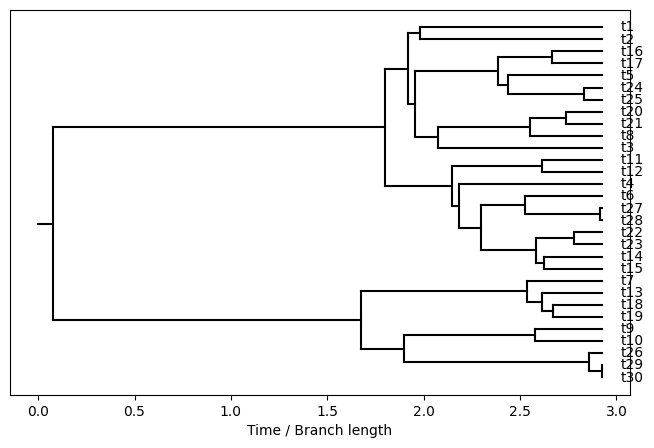

In [8]:
tree.plot()

In [9]:
independent['t2'].values, independent['t4'].values

print(sum(independent['t4'].values == independent['t3'].values)/len(independent['t1'].values))

0.8761609907120743


# Postprocessing Analysis

In [27]:
rows = []
for sites in [100, 200, 500, 1000, 2000]:
    for seed in [1, 2, 3, 4, 5]:
        prefix = f'run_sites{sites}_seed{seed}'
        dataset = pd.read_csv(f"{prefix}/{prefix}_tree_comparison_results.csv")
        
        for rf in dataset['RF']:
            rows.append({
                "sites": sites,
                "seed": seed,
                "RF": rf
            })

df_long = pd.DataFrame(rows)

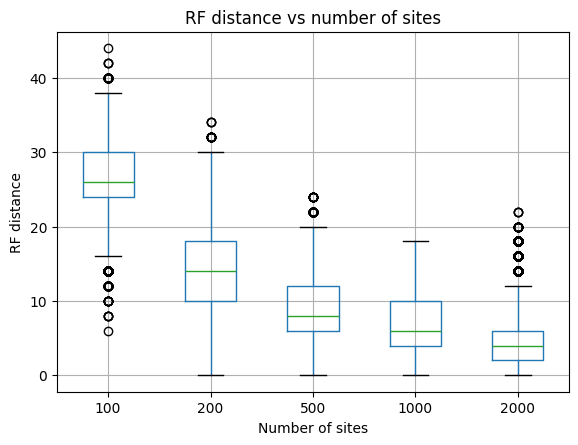

In [29]:
df_summary = df_long.groupby("sites")["RF"].agg(["mean", "std"])
df_long.boxplot(column="RF", by="sites")
plt.title("RF distance vs number of sites")
plt.suptitle("")
plt.xlabel("Number of sites")
plt.ylabel("RF distance")
plt.show()